In [ ]:
# ========================= CONFIG & IMPORTS =========================
import math
import torch
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # set before any CUDA ops
import torch.nn.functional as F
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
import warnings
warnings.filterwarnings("ignore")

MODEL_NAME = "gpt2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
LONG_TEXTS = {
    # Existing ~210–230 token entries
   "(≈230 tokens) Narrative — Moby-Dick ": (
        "Call me Ishmael. Some years ago—never mind how long precisely—having little or no money in my purse, and "
        "nothing particular to interest me on shore, I thought I would sail about a little and see the watery part of the "
        "world. It is a way I have of driving off the spleen and regulating the circulation. Whenever I find myself growing "
        "grim about the mouth; whenever it is a damp, drizzly November in my soul; whenever I find myself involuntarily "
        "pausing before coffin warehouses, and bringing up the rear of every funeral I meet; and especially whenever my "
        "hypos get such an upper hand of me, that it requires a strong moral principle to prevent me from deliberately "
        "stepping into the street, and methodically knocking people’s hats off—then, I account it high time to get to sea "
        "as soon as I can. There is nothing surprising in this. If they but knew it, almost all men in their degree, some "
        "time or other, cherish very nearly the same feelings towards the ocean with me."
    ),

    "(≈220 tokens) Technical — Einstein Relativity": (
        "Hitherto I have often spoken of a ‘railway carriage’ as an example of a rigid body which may be set into motion. "
        "We will now imagine a very long train travelling along the rails with a constant velocity v and a straight track. "
        "Let us suppose that an observer who is sitting in the middle of the train applies at the same instant two lightning "
        "flashes, one at the front and one at the rear end of the train, and that these flashes are reflected back to him by "
        "mirrors placed there. If the train were at rest, the light would take the same time to travel from the middle to the "
        "two ends and back; but if the train is moving, then the distances to be traveled by the light differ, and so, too, "
        "do the times required. The observer may thus be led to declare two events ‘simultaneous’ or ‘not simultaneous’ "
        "according to his state of motion. We arrive therefore at the important result that simultaneity is not an absolute "
        "concept, but depends on the observer’s inertial frame."
    ),

    "(≈210 tokens) Story — Alice in Wonderland": (
        "Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or "
        "twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, ‘and what "
        "is the use of a book,’ thought Alice ‘without pictures or conversations?’ So she was considering in her own mind "
        "(as well as she could, for the hot day made her feel very sleepy and stupid), whether the pleasure of making a "
        "daisy-chain would be worth the trouble of getting up and picking the daisies, when suddenly a White Rabbit with "
        "pink eyes ran close by her. There was nothing so very remarkable in that; nor did Alice think it so very much out "
        "of the way to hear the Rabbit say to itself, ‘Oh dear! Oh dear! I shall be too late!’ when she thought it over "
        "afterwards, it occurred to her that she ought to have wondered at this, but at the time it all seemed quite natural."
    ),

    # Shorter texts (~80–100 tokens)
    "(≈90 tokens) Short — News Summary": (
        "In a surprising turn of events, the city council voted unanimously to approve the new public transportation "
        "initiative, which will introduce electric buses and expand bike lanes across the downtown area. Proponents argue "
        "this move will reduce carbon emissions and ease traffic congestion, while critics question the cost and feasibility "
        "of implementing the plan within the proposed two-year timeframe."
    ),

    "(≈85 tokens) Short — Tech Product Launch": (
        "Today, a leading technology company unveiled its latest smartphone model, featuring a foldable display, "
        "improved battery life, and advanced AI-powered camera capabilities. Industry analysts predict strong consumer "
        "demand despite the higher price point, citing the device’s innovative design and premium features as key drivers "
        "of its appeal in a competitive market."
    ),

    # Longer texts (~400–500 tokens)
    "(≈450 tokens) Long — Climate Change Report": (
        "The latest climate change report from the Intergovernmental Panel on Climate Change (IPCC) paints a stark picture "
        "of the current state of the planet’s climate. Global average temperatures have risen by more than 1.1 degrees Celsius "
        "since pre-industrial times, and scientists warn that without drastic reductions in greenhouse gas emissions, we could "
        "see temperature increases exceeding 2 degrees Celsius within this century. The consequences of such warming include "
        "more frequent and severe heatwaves, prolonged droughts, intensified storms, and rising sea levels that threaten "
        "coastal communities worldwide. The report emphasizes that while the window for action is rapidly closing, there are "
        "still opportunities to mitigate the worst impacts if governments, industries, and individuals take immediate and "
        "coordinated action. Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring "
        "forests, and adopting sustainable agricultural practices are among the critical strategies outlined. Additionally, the "
        "report underscores the importance of climate adaptation measures to help communities prepare for unavoidable changes. "
        "This includes building resilient infrastructure, developing early warning systems, and ensuring access to resources for "
        "those most vulnerable to climate-related disruptions. The IPCC calls for unprecedented global cooperation and political "
        "will, noting that the cost of inaction far outweighs the investments needed to address the crisis. As the world faces "
        "this defining challenge, the report serves as both a warning and a roadmap for securing a sustainable future."
    ),

    "(≈420 tokens) Long — Space Exploration History": (
        "Humanity’s journey into space began in the mid-20th century, fueled by a combination of scientific curiosity, "
        "geopolitical rivalry, and the desire to push the boundaries of human capability. The launch of Sputnik 1 by the Soviet "
        "Union in 1957 marked the dawn of the space age, capturing the world’s imagination and sparking a race between superpowers. "
        "Just four years later, Yuri Gagarin became the first human to orbit the Earth, a milestone that demonstrated both the "
        "promise and peril of space exploration. The United States responded with the Apollo program, culminating in the historic "
        "Apollo 11 mission of 1969, when Neil Armstrong and Buzz Aldrin set foot on the Moon. In the decades that followed, space "
        "exploration expanded beyond national rivalries, with international collaborations such as the International Space Station "
        "becoming symbols of peaceful cooperation. Advances in technology have made it possible to explore the outer planets, land "
        "rovers on Mars, and send probes beyond the solar system. Today, space exploration is entering a new era, driven by both "
        "government agencies and private companies. Ambitious plans include returning humans to the Moon, establishing a sustainable "
        "presence there, and eventually sending crewed missions to Mars. These efforts promise to expand our understanding of the "
        "universe, inspire future generations, and potentially secure humanity’s long-term survival by making us a multi-planetary "
        "species."
    ),

}

# Merge into existing TEST_SENTENCES (kept from your config)
TEST_SENTENCES =LONG_TEXTS


LATENT_RANKS = [4, 8, 16, 32, 64]

In [ ]:
def split_heads(x, n_head):
    """[B,T,C] -> [B,H,T,Dh]"""
    B, T, C = x.shape
    Dh = C // n_head
    return x.view(B, T, n_head, Dh).transpose(1, 2).contiguous()


In [ ]:
def merge_heads(x):
    """[B,H,T,Dh] -> [B,T,C]"""
    B, H, T, Dh = x.shape
    return x.transpose(1, 2).contiguous().view(B, T, H * Dh)


In [ ]:
def causal_mask(T, device):
    """Lower-triangular mask [T,T] (True = keep)"""
    return torch.ones(T, T, device=device, dtype=torch.bool).tril()


In [ ]:
def scaled_dot_product_attention(Q, K, V, mask_bool):
    Dh = Q.size(-1)
    # Transpose last two dims so K is [B, H, Dh, T] for correct QK^T multiplication in attention
    # Scale by sqrt(Dh) to keep dot-product magnitudes stable, preventing softmax from becoming over-confident
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Dh)
    scores = scores.masked_fill(~mask_bool, float("-inf"))
    attn = torch.softmax(scores, dim=-1)
    ctx = torch.matmul(attn, V)
    return attn, ctx

In [ ]:
def cosine_similarity_batch(A, B, dim=-1, eps=1e-8):
    A_norm = A / (A.norm(dim=dim, keepdim=True) + eps)
    B_norm = B / (B.norm(dim=dim, keepdim=True) + eps)
    return float((A_norm * B_norm).sum(dim=dim).mean())

In [ ]:
def svd_compress_kv_per_head(K, V, rank):
    B, H, T, Dh = K.shape
    actual_rank = min(rank, T, Dh)

    K_comp = torch.zeros(B, H, T, actual_rank, device=K.device, dtype=K.dtype)
    V_comp = torch.zeros(B, H, T, actual_rank, device=V.device, dtype=V.dtype)
    K_basis = torch.zeros(B, H, Dh, actual_rank, device=K.device, dtype=K.dtype)
    V_basis = torch.zeros(B, H, Dh, actual_rank, device=V.device, dtype=V.dtype)

    for b in range(B):
        for h in range(H):
            # K SVD
            K_bh = K[b, h].to(torch.float32)
            U_k, _, _ = torch.linalg.svd(K_bh.T, full_matrices=False)
            K_basis[b, h] = U_k[:, :actual_rank].to(K.dtype)
            K_comp[b, h] = torch.einsum("td,dr->tr", K_bh, K_basis[b, h])

            # V SVD
            V_bh = V[b, h].to(torch.float32)
            U_v, _, _ = torch.linalg.svd(V_bh.T, full_matrices=False)
            V_basis[b, h] = U_v[:, :actual_rank].to(V.dtype)
            V_comp[b, h] = torch.einsum("td,dr->tr", V_bh, V_basis[b, h])

    return K_comp, V_comp, K_basis, V_basis, actual_rank

In [ ]:

def reconstruct_kv(K_comp, V_comp, K_basis, V_basis):
    K_rec = torch.einsum("bhtr,bhdr->bhtd", K_comp, K_basis)
    V_rec = torch.einsum("bhtr,bhdr->bhtd", V_comp, V_basis)
    return K_rec, V_rec

In [ ]:
def calculate_compression_stats(K_orig, V_orig, K_comp, V_comp, K_basis, V_basis):
    orig_elems = K_orig.numel() + V_orig.numel()
    comp_elems = K_comp.numel() + V_comp.numel() + K_basis.numel() + V_basis.numel()
    ratio = orig_elems / comp_elems
    red = (1 - comp_elems / orig_elems) * 100
    return dict(
        original_elements=orig_elems,
        compressed_elements=comp_elems,
        compression_ratio=ratio,
        memory_reduction_percent=red
    )

In [ ]:
def run_compression_analysis(sentence, sentence_name, model, tokenizer, n_head, head_dim):

    tokens = tokenizer(sentence, return_tensors="pt", add_special_tokens=False).to(DEVICE)
    input_ids = tokens["input_ids"]
    T = input_ids.size(1)
    with torch.no_grad():
        wte = model.transformer.wte
        # print("wte", wte) #Embedding(50257, 768)
        wpe = model.transformer.wpe
        # print("wpe", wpe) #Embedding(1024, 768)

        pos_ids = torch.arange(T, device=DEVICE).unsqueeze(0)
        embeddings = (wte(input_ids) + wpe(pos_ids)).to(DTYPE)

    block = model.transformer.h[0] # takes first layer of transformer

    W = block.attn.c_attn.weight.to(DTYPE)
    b = block.attn.c_attn.bias.to(DTYPE)
    qkv = embeddings @ W + b
    d_model = embeddings.size(-1)
    Q, K, V = torch.split(qkv, d_model, dim=-1)
    Qh = split_heads(Q, n_head)
    Kh = split_heads(K, n_head)
    Vh = split_heads(V, n_head)

    mask = causal_mask(T, DEVICE).unsqueeze(0).unsqueeze(0).expand(Qh.size(0), Qh.size(1), T, T)
    attn_base, ctx_base = scaled_dot_product_attention(Qh, Kh, Vh, mask)

    rows = []
    for rank in LATENT_RANKS:

       # Skip this rank if it's >= min(T, head_dim) because SVD rank cannot exceed the smaller of sequence length or head dimension
        if rank >= min(T, head_dim):
            continue
        Kc, Vc, Kb, Vb, r = svd_compress_kv_per_head(Kh, Vh, rank)
        Krec, Vrec = reconstruct_kv(Kc, Vc, Kb, Vb)

        attn_comp, ctx_comp = scaled_dot_product_attention(Qh, Krec, Vrec, mask)

        stats = calculate_compression_stats(Kh, Vh, Kc, Vc, Kb, Vb)
        k_sim = cosine_similarity_batch(Kh, Krec, dim=-1)
        v_sim = cosine_similarity_batch(Vh, Vrec, dim=-1)
        a_sim = cosine_similarity_batch(attn_base, attn_comp, dim=-1)
        c_sim = cosine_similarity_batch(ctx_base, ctx_comp, dim=-1)

        rows.append({
            "sentence": sentence_name,
            "sequence_length": T,
            "rank": r,
            "compression_ratio": stats["compression_ratio"],
            "memory_reduction": stats["memory_reduction_percent"],
            "k_similarity": k_sim,
            "v_similarity": v_sim,
            "attention_similarity": a_sim,
            "context_similarity": c_sim,
            "quality_score": (k_sim + v_sim + a_sim + c_sim) / 4.0
        })

    return rows


In [ ]:
def main():
    print("🚀 Loading GPT-2...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()

    n_head = model.config.n_head
    d_model = model.config.n_embd
    head_dim = d_model // n_head

    print(f"📊 Model: Heads={n_head}, d_model={d_model}, head_dim={head_dim}, device={DEVICE}")

    all_rows = []
    for name, sent in TEST_SENTENCES.items():
        print(f"\n🔍 {name}")
        rows = run_compression_analysis(sent, name, model, tokenizer, n_head, head_dim)
        all_rows.extend(rows)

    results_df = pd.DataFrame(all_rows)

    print("\n" + "="*80)
    print("📈 RESULTS (concise)")
    print("="*80)
    if len(results_df) == 0:
        print("No rows generated.")
        return results_df

    print(f"\nOverall:")
    print(f"• Avg Memory Reduction: {results_df['memory_reduction'].mean():.1f}%")
    print(f"• Avg Quality Score:   {results_df['quality_score'].mean():.3f}")
    print(f"• Best Memory Reduct.: {results_df['memory_reduction'].max():.1f}%")
    print(f"• Best Quality Score:  {results_df['quality_score'].max():.3f}")

    header = f"{'Type':<14} {'Len':>4} {'Rank':>4} {'Mem%':>6} {'Comp':>6} {'Qual':>6} {'K':>6} {'V':>6} {'Att':>6} {'Ctx':>6}"
    print("\n" + header)
    print("-" * len(header))
    for s in results_df['sentence'].unique():
        s_df = results_df[results_df['sentence'] == s].sort_values('rank')
        for _, r in s_df.iterrows():
            print(f"{s[:13]:<14} "
                  f"{int(r['sequence_length']):>4} "
                  f"{int(r['rank']):>4} "
                  f"{r['memory_reduction']:>6.1f} "
                  f"{r['compression_ratio']:>6.2f} "
                  f"{r['quality_score']:>6.3f} "
                  f"{r['k_similarity']:>6.3f} "
                  f"{r['v_similarity']:>6.3f} "
                  f"{r['attention_similarity']:>6.3f} "
                  f"{r['context_similarity']:>6.3f}")

    return results_df


In [ ]:
if __name__ == "__main__":
    results_df = main()

🚀 Loading GPT-2...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

📊 Model: Heads=12, d_model=768, head_dim=64, device=cuda

🔍 (≈230 tokens) Narrative — Moby-Dick 

🔍 (≈220 tokens) Technical — Einstein Relativity

🔍 (≈210 tokens) Story — Alice in Wonderland

🔍 (≈90 tokens) Short — News Summary

🔍 (≈85 tokens) Short — Tech Product Launch

🔍 (≈450 tokens) Long — Climate Change Report

🔍 (≈420 tokens) Long — Space Exploration History

📈 RESULTS (concise)

Overall:
• Avg Memory Reduction: 65.4%
• Avg Quality Score:   0.946
• Best Memory Reduct.: 92.3%
• Best Quality Score:  0.996

Type            Len Rank   Mem%   Comp   Qual      K      V    Att    Ctx
-------------------------------------------------------------------------
(≈230 tokens)   212    4   91.9  12.29  0.885  0.972  0.870  0.813  0.887
(≈230 tokens)   212    8   83.7   6.14  0.938  0.980  0.911  0.923  0.937
(≈230 tokens)   212   16   67.5   3.07  0.966  0.988  0.948  0.965  0.964
(≈230 tokens)   212   32   34.9   1.54  0.989  0.996  0.981  0.991  0.987
(≈220 tokens)   217    4   91.9  12.36 

In [ ]:
# ----------------- Seaborn Single-Plot Visualizations -----------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Global styling (Seaborn) ----------
sns.set_theme(style="whitegrid", context="talk", font="DejaVu Sans")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.edgecolor": "#2c3e50",
    "axes.linewidth": 1.2
})

def _truncate_labels(vals, maxlen=22):
    out = []
    for s in vals:
        s = str(s)
        out.append(s if len(s) <= maxlen else s[:maxlen-1] + "…")
    return out

def _ensure_outdir(outdir):
    os.makedirs(outdir, exist_ok=True)
    return os.path.abspath(outdir)

# ---------- 1) Memory Reduction Heatmap (single image) ----------
def plot_memory_heatmap_seaborn(results_df: pd.DataFrame, outdir="plots_seaborn", dpi=300):
    _ensure_outdir(outdir)
    pivot_mem = results_df.pivot_table(index="sentence", columns="rank",
                                       values="memory_reduction", aggfunc="mean").sort_index()
    pivot_mem = pivot_mem.reindex(sorted(pivot_mem.columns), axis=1)

    h = max(3.5, 0.45 * len(pivot_mem))  # dynamic height per rows
    fig, ax = plt.subplots(figsize=(12, h), constrained_layout=True)
    g = sns.heatmap(
        pivot_mem,
        ax=ax,
        cmap="YlGn",
        annot=True,
        fmt=".1f",
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Memory Reduction (%)"}
    )
    ax.set_title("Memory Reduction Efficiency (Higher is Better)", pad=14, weight="bold")
    ax.set_xlabel("Compression Rank")
    ax.set_ylabel("Text Scenarios")
    ax.set_xticklabels([f"R{int(x.get_text())}" for x in ax.get_xticklabels()], rotation=0)
    ax.set_yticklabels(_truncate_labels([t.get_text() for t in ax.get_yticklabels()]), rotation=0)

    for s in ax.spines.values():
        s.set_linewidth(1.4); s.set_color("#2c3e50")

    out = os.path.join(outdir, "memory_heatmap.png")
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    return fig, out

# ---------- 2) Quality Score Heatmap (single image) ----------
def plot_quality_heatmap_seaborn(results_df: pd.DataFrame, outdir="plots_seaborn", dpi=300):
    _ensure_outdir(outdir)
    pivot_qual = results_df.pivot_table(index="sentence", columns="rank",
                                        values="quality_score", aggfunc="mean").sort_index()
    pivot_qual = pivot_qual.reindex(sorted(pivot_qual.columns), axis=1)

    h = max(3.5, 0.45 * len(pivot_qual))
    fig, ax = plt.subplots(figsize=(12, h), constrained_layout=True)
    g = sns.heatmap(
        pivot_qual,
        ax=ax,
        cmap="mako",
        annot=True,
        fmt=".3f",
        linewidths=0.6,
        linecolor="white",
        cbar_kws={"label": "Quality Score"}
    )
    ax.set_title("Quality Preservation (Closer to 1.0 is Better)", pad=14, weight="bold")
    ax.set_xlabel("Compression Rank")
    ax.set_ylabel("Text Scenarios")
    ax.set_xticklabels([f"R{int(x.get_text())}" for x in ax.get_xticklabels()], rotation=0)
    ax.set_yticklabels(_truncate_labels([t.get_text() for t in ax.get_yticklabels()]), rotation=0)

    for s in ax.spines.values():
        s.set_linewidth(1.4); s.set_color("#2c3e50")

    out = os.path.join(outdir, "quality_heatmap.png")
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    return fig, out

# ---------- 3) Pareto Frontier (single image) ----------
def plot_pareto_frontier_seaborn(results_df: pd.DataFrame, outdir="plots_seaborn", dpi=300):
    _ensure_outdir(outdir)

    fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
    sns.scatterplot(
        data=results_df,
        x="memory_reduction",
        y="quality_score",
        hue="sentence",
        palette="tab10",
        s=140,
        edgecolor="white",
        linewidth=1.4,
        ax=ax,
        alpha=0.9
    )

    # annotate each point with its rank
    for _, row in results_df.iterrows():
        ax.annotate(f"R{int(row['rank'])}",
                    (row["memory_reduction"], row["quality_score"]),
                    xytext=(7, 7), textcoords="offset points",
                    fontsize=10, weight="bold",
                    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.95, edgecolor="#555"))

    # Compute non-dominated Pareto frontier
    pts = results_df[["memory_reduction", "quality_score"]].to_numpy()
    pareto_idx = []
    for i, p in enumerate(pts):
        dominated = False
        for j, q in enumerate(pts):
            if j == i:
                continue
            # q dominates p if q >= p in both and strictly better in at least one
            if (q[0] >= p[0]) and (q[1] >= p[1]) and ((q[0] > p[0]) or (q[1] > p[1])):
                dominated = True
                break
        if not dominated:
            pareto_idx.append(i)

    pareto_df = results_df.iloc[pareto_idx].sort_values(by="memory_reduction")
    if not pareto_df.empty:
        ax.plot(pareto_df["memory_reduction"], pareto_df["quality_score"],
                linewidth=3, color="#2c3e50", alpha=0.9, label="Pareto Frontier")
        ax.legend(title="Sentence", loc="best", frameon=True)

    ax.set_xlabel("Memory Reduction (%)")
    ax.set_ylabel("Quality Score")
    ax.set_title("Compression Pareto Frontier: Memory vs Quality", pad=14, weight="bold")

    out = os.path.join(outdir, "pareto_frontier.png")
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    return fig, out

# ---------- 4) Rank-wise single-line plots (each is a separate image) ----------
def _rank_aggregate(results_df: pd.DataFrame):
    rank_avg = results_df.groupby("rank").agg({
        "memory_reduction": ["mean", "std"],
        "quality_score": ["mean", "std"],
        "compression_ratio": ["mean", "std"],
        "context_similarity": ["mean", "std"]
    }).reset_index()
    rank_avg.columns = ["rank",
                        "memory_reduction_mean","memory_reduction_std",
                        "quality_score_mean","quality_score_std",
                        "compression_ratio_mean","compression_ratio_std",
                        "context_similarity_mean","context_similarity_std"]
    # NaN std -> 0
    for c in ["memory_reduction_std","quality_score_std","compression_ratio_std","context_similarity_std"]:
        rank_avg[c] = rank_avg[c].fillna(0.0)
    return rank_avg

def _single_metric_lineplot(rank_avg: pd.DataFrame, y_mean: str, y_std: str, y_label: str,
                            title: str, filename: str, outdir="plots_seaborn", dpi=300):
    _ensure_outdir(outdir)
    fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
    sns.lineplot(
        data=rank_avg,
        x="rank",
        y=y_mean,
        marker="o",
        markersize=8,
        linewidth=3,
        ax=ax
    )
    # Std band
    ax.fill_between(rank_avg["rank"],
                    rank_avg[y_mean] - rank_avg[y_std],
                    rank_avg[y_mean] + rank_avg[y_std],
                    alpha=0.18)

    # Value labels
    for x, y in zip(rank_avg["rank"], rank_avg[y_mean]):
        ax.annotate(f"{y:.3f}" if "Score" in y_label or "Similarity" in y_label else f"{y:.2f}",
                    (x, y), textcoords="offset points", xytext=(0, 10), ha="center",
                    fontsize=10, weight="bold")

    ax.set_xlabel("Compression Rank")
    ax.set_ylabel(y_label)
    ax.set_title(title, pad=14, weight="bold")
    out = os.path.join(outdir, filename)
    fig.savefig(out, dpi=dpi, bbox_inches="tight", facecolor="white")
    return fig, out

def plot_rank_series_seaborn(results_df: pd.DataFrame, outdir="plots_seaborn", dpi=300):
    rank_avg = _rank_aggregate(results_df)
    outs = []
    outs.append(_single_metric_lineplot(rank_avg,
                "memory_reduction_mean", "memory_reduction_std",
                "Memory Reduction (%)",
                "Memory Reduction by Rank (Higher is Better)",
                "rank_memory.png", outdir, dpi))
    outs.append(_single_metric_lineplot(rank_avg,
                "quality_score_mean", "quality_score_std",
                "Quality Score",
                "Quality Preservation by Rank (Closer to 1.0 is Better)",
                "rank_quality.png", outdir, dpi))
    outs.append(_single_metric_lineplot(rank_avg,
                "compression_ratio_mean", "compression_ratio_std",
                "Compression Ratio (×)",
                "Compression Ratio by Rank (Higher is Better)",
                "rank_compression_ratio.png", outdir, dpi))
    outs.append(_single_metric_lineplot(rank_avg,
                "context_similarity_mean", "context_similarity_std",
                "Context Similarity",
                "Context Preservation by Rank (Higher is Better)",
                "rank_context_similarity.png", outdir, dpi))
    return outs

# ---------- Orchestrator: save each plot as its own image ----------
def export_all_seaborn_plots(results_df: pd.DataFrame, outdir="plots_seaborn", dpi=300):
    print("🎨 Generating Seaborn single-plot images…")
    _ensure_outdir(outdir)
    figs = []
    figs.append(plot_memory_heatmap_seaborn(results_df, outdir, dpi))
    figs.append(plot_quality_heatmap_seaborn(results_df, outdir, dpi))
    figs.append(plot_pareto_frontier_seaborn(results_df, outdir, dpi))
    figs.extend(plot_rank_series_seaborn(results_df, outdir, dpi))
    print(f"✅ Saved PNGs to: {_ensure_outdir(outdir)}")
    # Show one-by-one if you want previews
    for f, _ in figs: plt.show(block=False)
    return figs


🎨 Generating Seaborn single-plot images…
✅ Saved PNGs to: /content/plots_seaborn


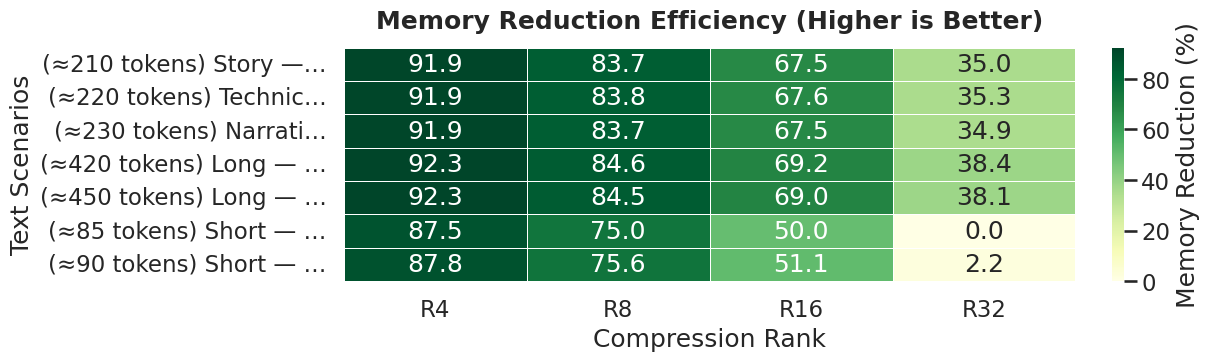

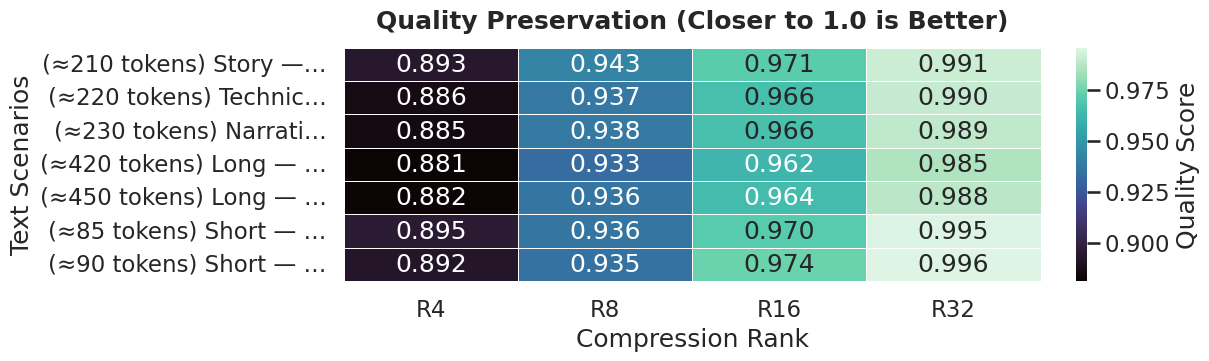

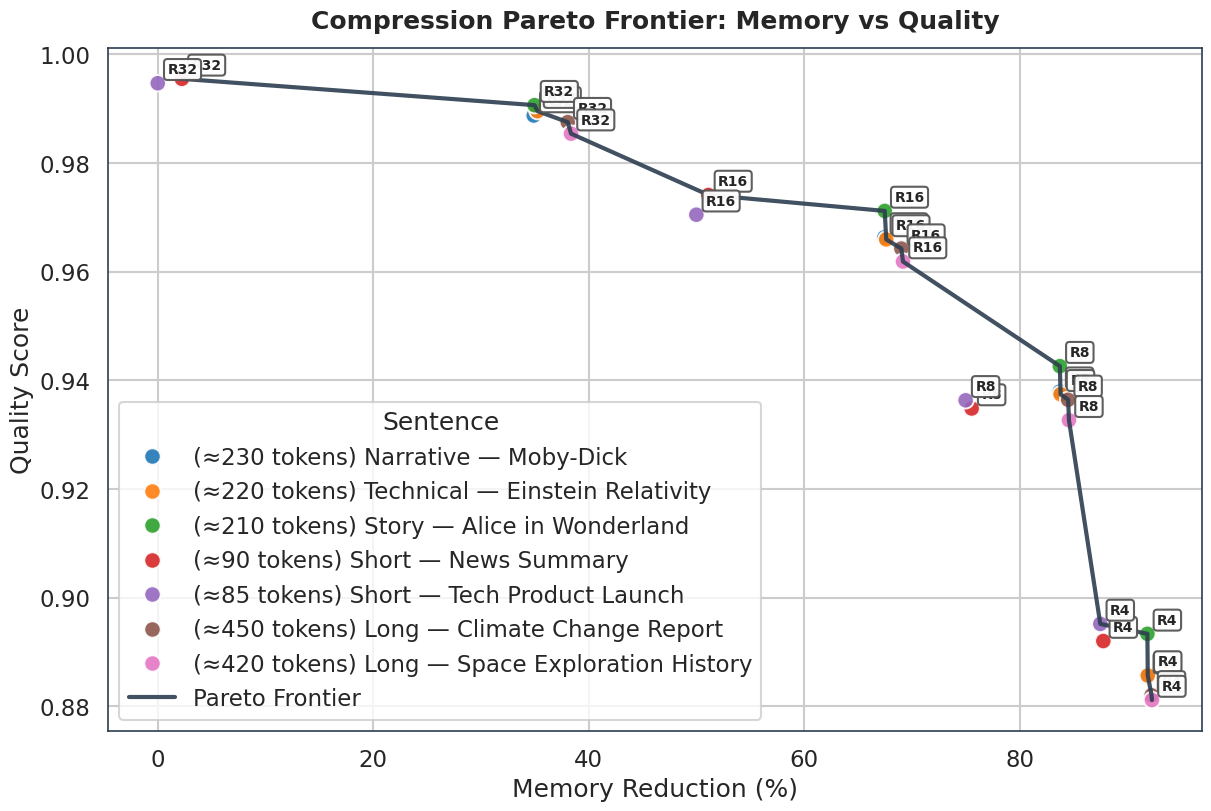

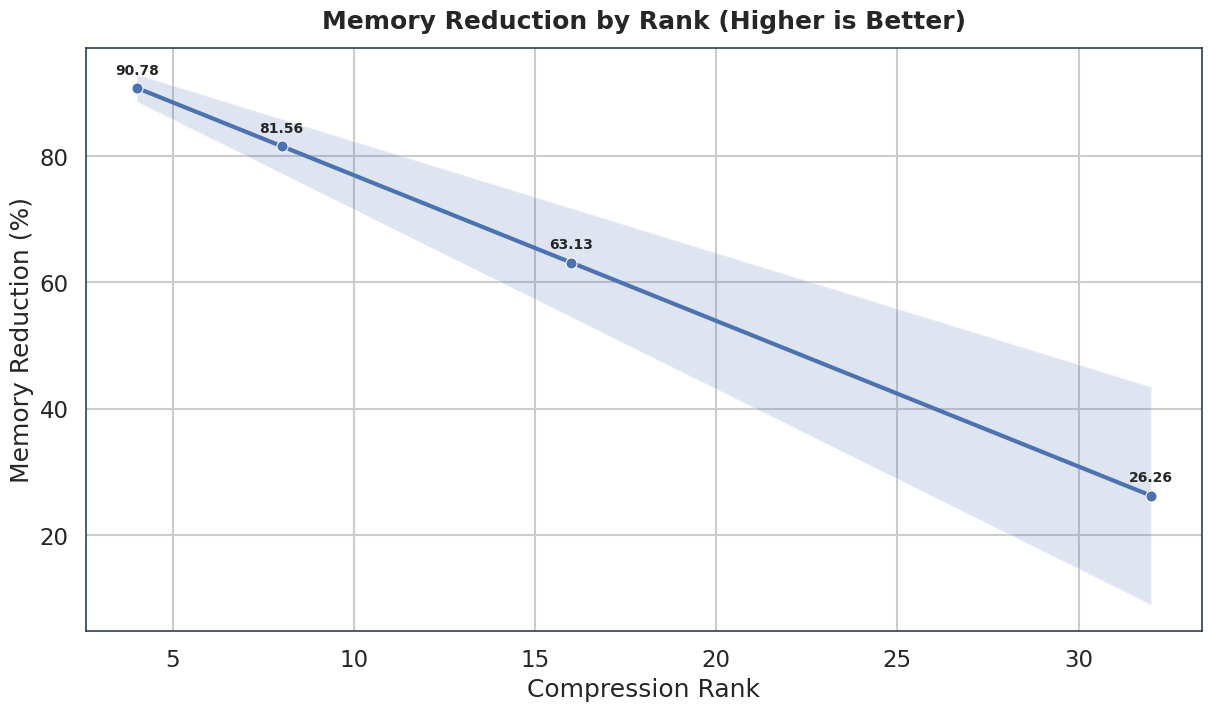

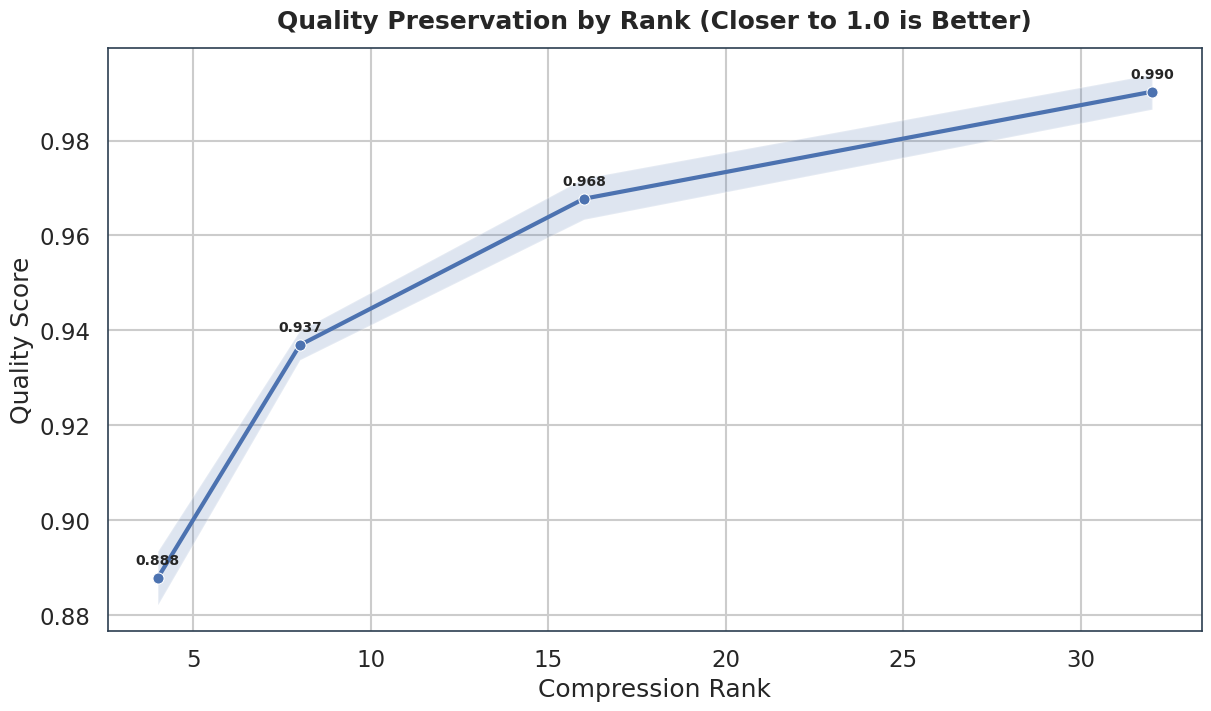

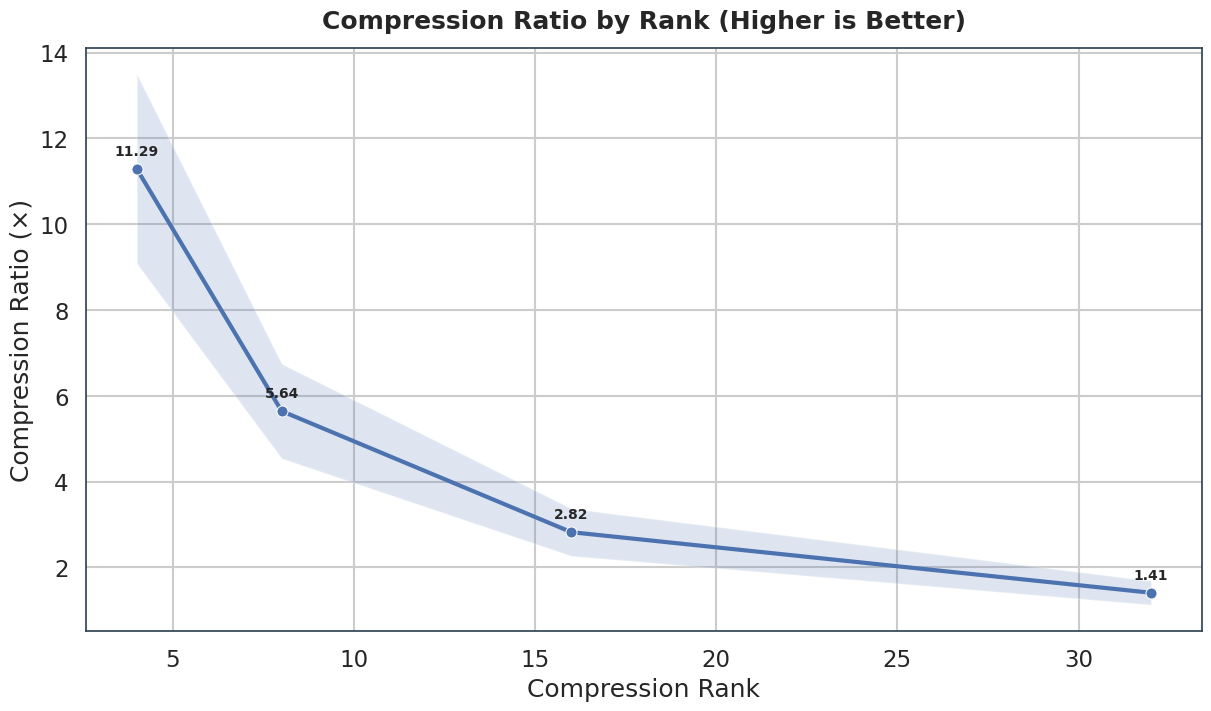

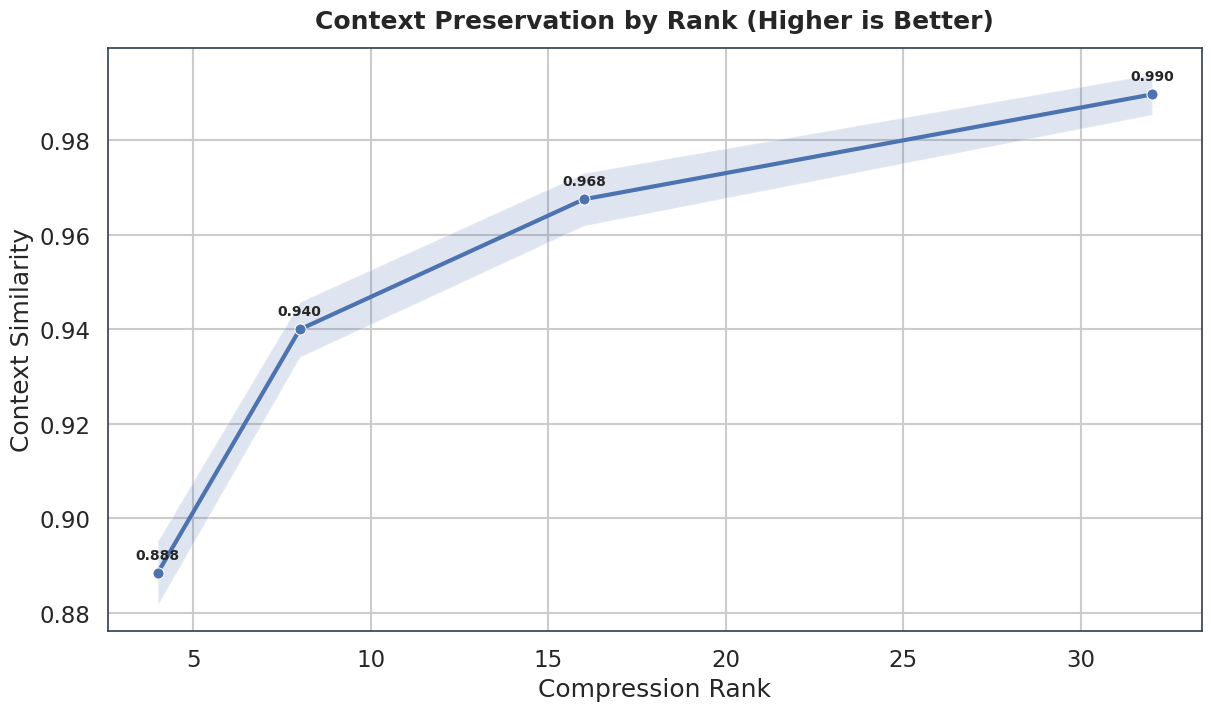

[(<Figure size 1200x350 with 2 Axes>, 'plots_seaborn/memory_heatmap.png'),
 (<Figure size 1200x350 with 2 Axes>, 'plots_seaborn/quality_heatmap.png'),
 (<Figure size 1200x800 with 1 Axes>, 'plots_seaborn/pareto_frontier.png'),
 (<Figure size 1200x700 with 1 Axes>, 'plots_seaborn/rank_memory.png'),
 (<Figure size 1200x700 with 1 Axes>, 'plots_seaborn/rank_quality.png'),
 (<Figure size 1200x700 with 1 Axes>,
  'plots_seaborn/rank_compression_ratio.png'),
 (<Figure size 1200x700 with 1 Axes>,
  'plots_seaborn/rank_context_similarity.png')]

In [ ]:
export_all_seaborn_plots(results_df, outdir="plots_seaborn", dpi=200)